# Chapter 15: Моделирование последовательных данных с помощью рекуррентных неиронных сетей (Часть 2)

In [1]:
from IPython.display import Image
import torch
import torch.nn as nn
%matplotlib inline

## 15.3.  Реализация RNN для моделирования последовательностей в PyTorch 


Ознакомившись с теоретическими основами RNN,  мы готовы перейти к более практи­ческой части этой главы - реализации RNN  в PyTorch.  В оставшейся части главы мы 
будем применять RNN  к двум распространенным задачам: 
1. Анализ эмоциональной окраски (sentiment analysis). 
2. Языковое моделирование (language modeling). 

### 15.3.1. Проект № 1:  предсказание эмоциональной окраски отзывов на фильмы IMDb 

В главе 8  мы говорили о том, что анализ эмоциональной окраски (тональности) факти­чески означает анализ мнения, выраженного в предложении или текстовом документе. 
В этом разделе мы реализуем многослойную RNN  для анализа тональности текста с использованием архитектуры «многие к одному», а в следующем - реализуем RNN 
«многие  ко  многим» для  приложения языкового  моделирования.  Хотя выбранные примеры намеренно просты и предназначены для лишь ознакомления с  основными 
концепциями RNN,  языковое моделирование имеет широкий спектр интересных при­ менений - таких как создание чат-ботов, дающих компьютерам возможность напря­мую взаимодействовать с людьми, общаясь с ними на естественном языке. 

#### Подготовка данных отзывов на фильмы

In [15]:
# !pip install torchtext

Каждый набор состоит из 25  тыс. примеров, а каждый пример - из двух элементов: 
метки тональности,  которую в  итоге должна научиться предсказывать модель (neg означает негативную тональность, а pos - позитивную), и текста отзыва на фильм 
(входные признаки).\ 
Текстовый компонент этих отзывов представляет собой последо­вательности  слов,  и  модель RNN классифицирует каждую последовательность как положительный (1)  или отрицательный (0) отзыв.

Однако, прежде чем мы сможем передать данные в модель RNN,  нам нужно применить несколько шагов предварительной обработки: 
1. Разделить набор обучающих данных на отдельные разделы: для обучения и для ва­лидации. 
2. Определить уникальные слова в наборе обучающих данных. 
3. Сопоставить каждое уникальное слово с уникальным целым числом и закодировать 
текст отзыва в виде целых чисел (индексов каждого уникального слова). 
4. Разделить набор данных на мини-пакеты в качестве входных данных для модели.

In [2]:
import os
import torch
from torch.utils.data import Dataset, random_split

class IMDBDataset(Dataset):
    """
    Аналог torchtext.datasets.IMDB(split='train'/'test').
    Возвращает пары (label, text), где label — int (1 для pos, 0 для neg),
    text — сырая строка (как в новом API torchtext).
    """
    def __init__(self, root, split='train'):
        assert split in ('train', 'test')
        self.samples = []  # список кортежей (path, label)

        for label_name, label in (('pos', 1), ('neg', 0)):
            folder = os.path.join(root, split, label_name)
            if not os.path.isdir(folder):
                continue
            for fname in os.listdir(folder):
                if fname.endswith('.txt'):
                    self.samples.append((os.path.join(folder, fname), label))

        # Сортируем для воспроизводимости (os.listdir порядок не гарантирует)
        self.samples.sort()

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        with open(path, encoding='utf-8') as f:
            text = f.read()
        return label, text   # порядок как в новом API: (label, text)


# --- Аналог вашего кода ---
root = 'C:/Users/Bushi/OneDrive/Desktop/Scikit_Learn/Book/machine-learning-book-main/ch08/aclImdb'   # путь к папке aclImdb

train_dataset = IMDBDataset(root, split='train')
test_dataset  = IMDBDataset(root, split='test')

# Шаг 1. Разделить набор обучающих данных на отдельные разделы: для обучения и для ва­лидации. 

torch.manual_seed(1)
train_dataset, valid_dataset = random_split(list(train_dataset), [20000, 5000])

print('train:', len(train_dataset))
print('valid:', len(valid_dataset))
print('test :', len(test_dataset))

# Проверка
label, text = train_dataset[0]
print('label:', label)
print('text :', text[:200])

train: 20000
valid: 5000
test : 25000
label: 1
text : Fantastic documentary of 1924. This early 20th century geography of today's Iraq was powerful. Watch this and tell me if Cecil B. DeMille didn't take notes before making his The Ten Commandments. Meri


In [3]:
## Шаг 2: найти уникальные токены (слова)
import re
from collections import Counter, OrderedDict

token_counts = Counter()

def tokenizer(text):
    #  удалить HTML-теги.
    text = re.sub('<[^>]*>', '', text)
    # Ищем смайлики и сохраняем их в отдельный список emoticons
    emoticons = re.findall('(?::|;|=)(?:-)?(?:\)|\(|D|P)', text.lower())
    # \W — всё, что не входит в \w = [a-zA-Z0-9_] Смысл: все знаки препинания и прочий «мусор» превращаются в пробелы, слова остаются разделены пробелами.
    # К очищенному тексту приклеивается строка со смайликами.
    text = re.sub('[\W]+', ' ', text.lower()) + ' '.join(emoticons).replace('-', '')
    # Разбиваем итоговую строку по пробелам на список токенов. split() без аргументов режет по любым пробельным символам и выкидывает пустые строки.
    tokenized = text.split()
    return tokenized


for label, line in train_dataset:
    tokens = tokenizer(line)
    token_counts.update(tokens)
 
    
print('Paзмep словаря:', len(token_counts))

<>:11: SyntaxWarning: "\)" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\)"? A raw string is also an option.
<>:14: SyntaxWarning: "\W" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\W"? A raw string is also an option.
<>:11: SyntaxWarning: "\)" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\)"? A raw string is also an option.
<>:14: SyntaxWarning: "\W" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\W"? A raw string is also an option.
C:\Users\Bushi\AppData\Local\Temp\ipykernel_2252\2417843217.py:11: SyntaxWarning: "\)" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\)"? A raw string is also an option.
  emoticons = re.findall('(?::|;|=)(?:-)?(?:\)|\(|D|P)', text.lower())
C:\Users\Bushi\AppData\Local\Temp\ipykernel_2252\2417843217.py:14: SyntaxWarning: "\W" is an invali

Paзмep словаря: 69323


In [4]:
## Шаг 3: кодирование каждого уникального токена в целые числа

# 1) Отсортировать пары (слово, частота) по убыванию частоты
sorted_by_freq_tuples = sorted(token_counts.items(), key=lambda x: x[1], reverse=True)

# 2) Собрать OrderedDict с сохранением порядка
ordered_dict = OrderedDict(sorted_by_freq_tuples)

# 3) Строим словарь: сначала <pad>=0 и <unk>=1, потом все слова в порядке частоты
itos = ['<pad>', '<unk>']
stoi = {'<pad>': 0, '<unk>': 1}

for word in ordered_dict:
    if word in stoi:          # на случай, если "<pad>"/"<unk>" встретились в данных
        continue
    stoi[word] = len(itos)
    itos.append(word)

DEFAULT_INDEX = stoi['<unk>']  # аналог vocab.set_default_index(1)

# 4) Обёртка, имитирующая поведение torchtext.vocab.vocab
class Vocab:
    def __init__(self, itos, stoi, default_index):
        self.itos = itos                # index -> token
        self.stoi = stoi                # token -> index
        self.default_index = default_index

    def __getitem__(self, token):
        # vocab[token] -> int, для незнакомых возвращает default_index
        return self.stoi.get(token, self.default_index)

    def __len__(self):
        return len(self.itos)

    def __contains__(self, token):
        return token in self.stoi

    def lookup_token(self, index):
        return self.itos[index]

    def lookup_indices(self, tokens):
        return [self[t] for t in tokens]

vocab = Vocab(itos, stoi, DEFAULT_INDEX)

print([vocab[token] for token in ['this', 'is', 'an', 'example']])

[11, 7, 35, 464]


In [15]:
## Шаг 3-A: определить функции для преобразования

device = torch.device("cuda:0")
# device = 'cpu'

# [vocab[token] for token in ...] — для каждого токена берём его индекс из словаря (Шаг 3).
# Итог: text_pipeline(строка) → список целых чисел (индексов токенов)
text_pipeline = lambda x: [vocab[token] for token in tokenizer(x)]
label_pipeline = lambda x: float(x)
print(label_pipeline(0), label_pipeline(1))   # 0.0 1.0

## Шаг 3-B: обернуть функции кодирования и преобразования
def collate_batch(batch):
    # label_list — сюда сложим метки (float).
    # text_list — сюда сложим закодированные тексты (тензоры целых чисел).
    # lengths — сюда сложим длины этих текстов (сколько токенов в каждом).
    label_list, text_list, lengths = [], [], []
    for _label, _text in batch:
        label_list.append(label_pipeline(_label))
        processed_text = torch.tensor(text_pipeline(_text), 
                                      dtype=torch.int64)
        text_list.append(processed_text)
        lengths.append(processed_text.size(0))
    label_list = torch.tensor(label_list)
    lengths = torch.tensor(lengths)
    padded_text_list = nn.utils.rnn.pad_sequence(
        text_list, batch_first=True)
    return padded_text_list.to(device), label_list.to(device), lengths.to(device)

0.0 1.0


In [16]:
## Возьмём маленький батч

from torch.utils.data import DataLoader

#Создаётся DataLoader с параметрами:
# train_dataset — откуда брать данные. Это тот самый train_dataset из 20000 примеров.
# batch_size=4 — в каждом батче будет 4 примера. Маленькое число, чтобы удобно было распечатать и глазами проверить.
# shuffle=False — не перемешивать порядок. Нужно, чтобы результат был воспроизводимым: next(iter(...)) каждый раз давал одни и те же 4 примера.
# collate_fn=collate_batch — функция, которую DataLoader вызывает для сборки батча. Это та самая collate_batch из Шага 3-B: она кодирует текст, метки, 
# паддит и переносит на device.

# Что делает DataLoader при итерации:
# Берёт 4 примера из train_dataset (через __getitem__).
# Передаёт список этих 4 примеров в collate_batch.
# Возвращает то, что вернула collate_batch — кортеж (text_batch, label_batch, length_batch).

dataloader = DataLoader(train_dataset, batch_size=4, shuffle=False, collate_fn=collate_batch)
text_batch, label_batch, length_batch = next(iter(dataloader))
print(text_batch)
print(label_batch)
print(length_batch)
print(text_batch.shape)

tensor([[ 755,  662,    5,  ...,    0,    0,    0],
        [  40,   13,    4,  ...,    8,   13, 4000],
        [  24,  399,   28,  ...,    0,    0,    0],
        [  11, 2346,    5,  ...,    0,    0,    0]], device='cuda:0')
tensor([1., 1., 1., 0.], device='cuda:0')
tensor([110, 434, 148,  57], device='cuda:0')
torch.Size([4, 434])


In [17]:
## Шаг 4: разбиение датасетов на батчи

batch_size = 32  

train_dl = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_batch)
valid_dl = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_batch)
test_dl = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_batch)

### Слои встраивания для кодирования предложений

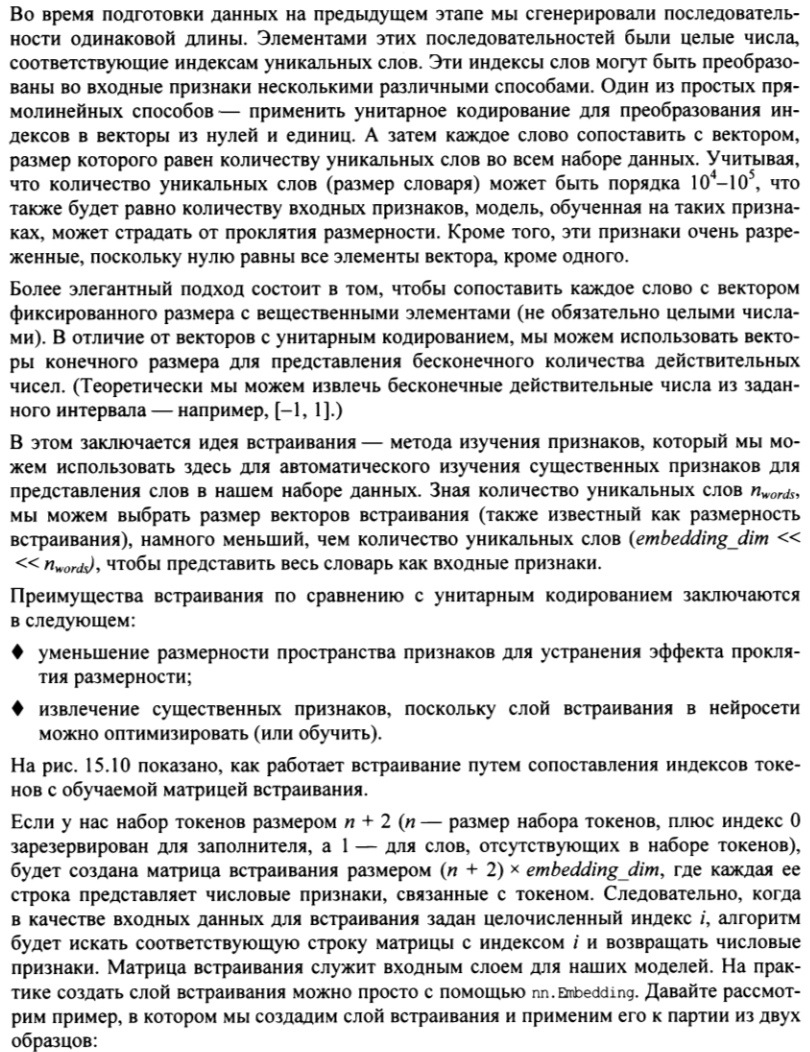

In [18]:
Image(filename='figures/text1.png', width=600)

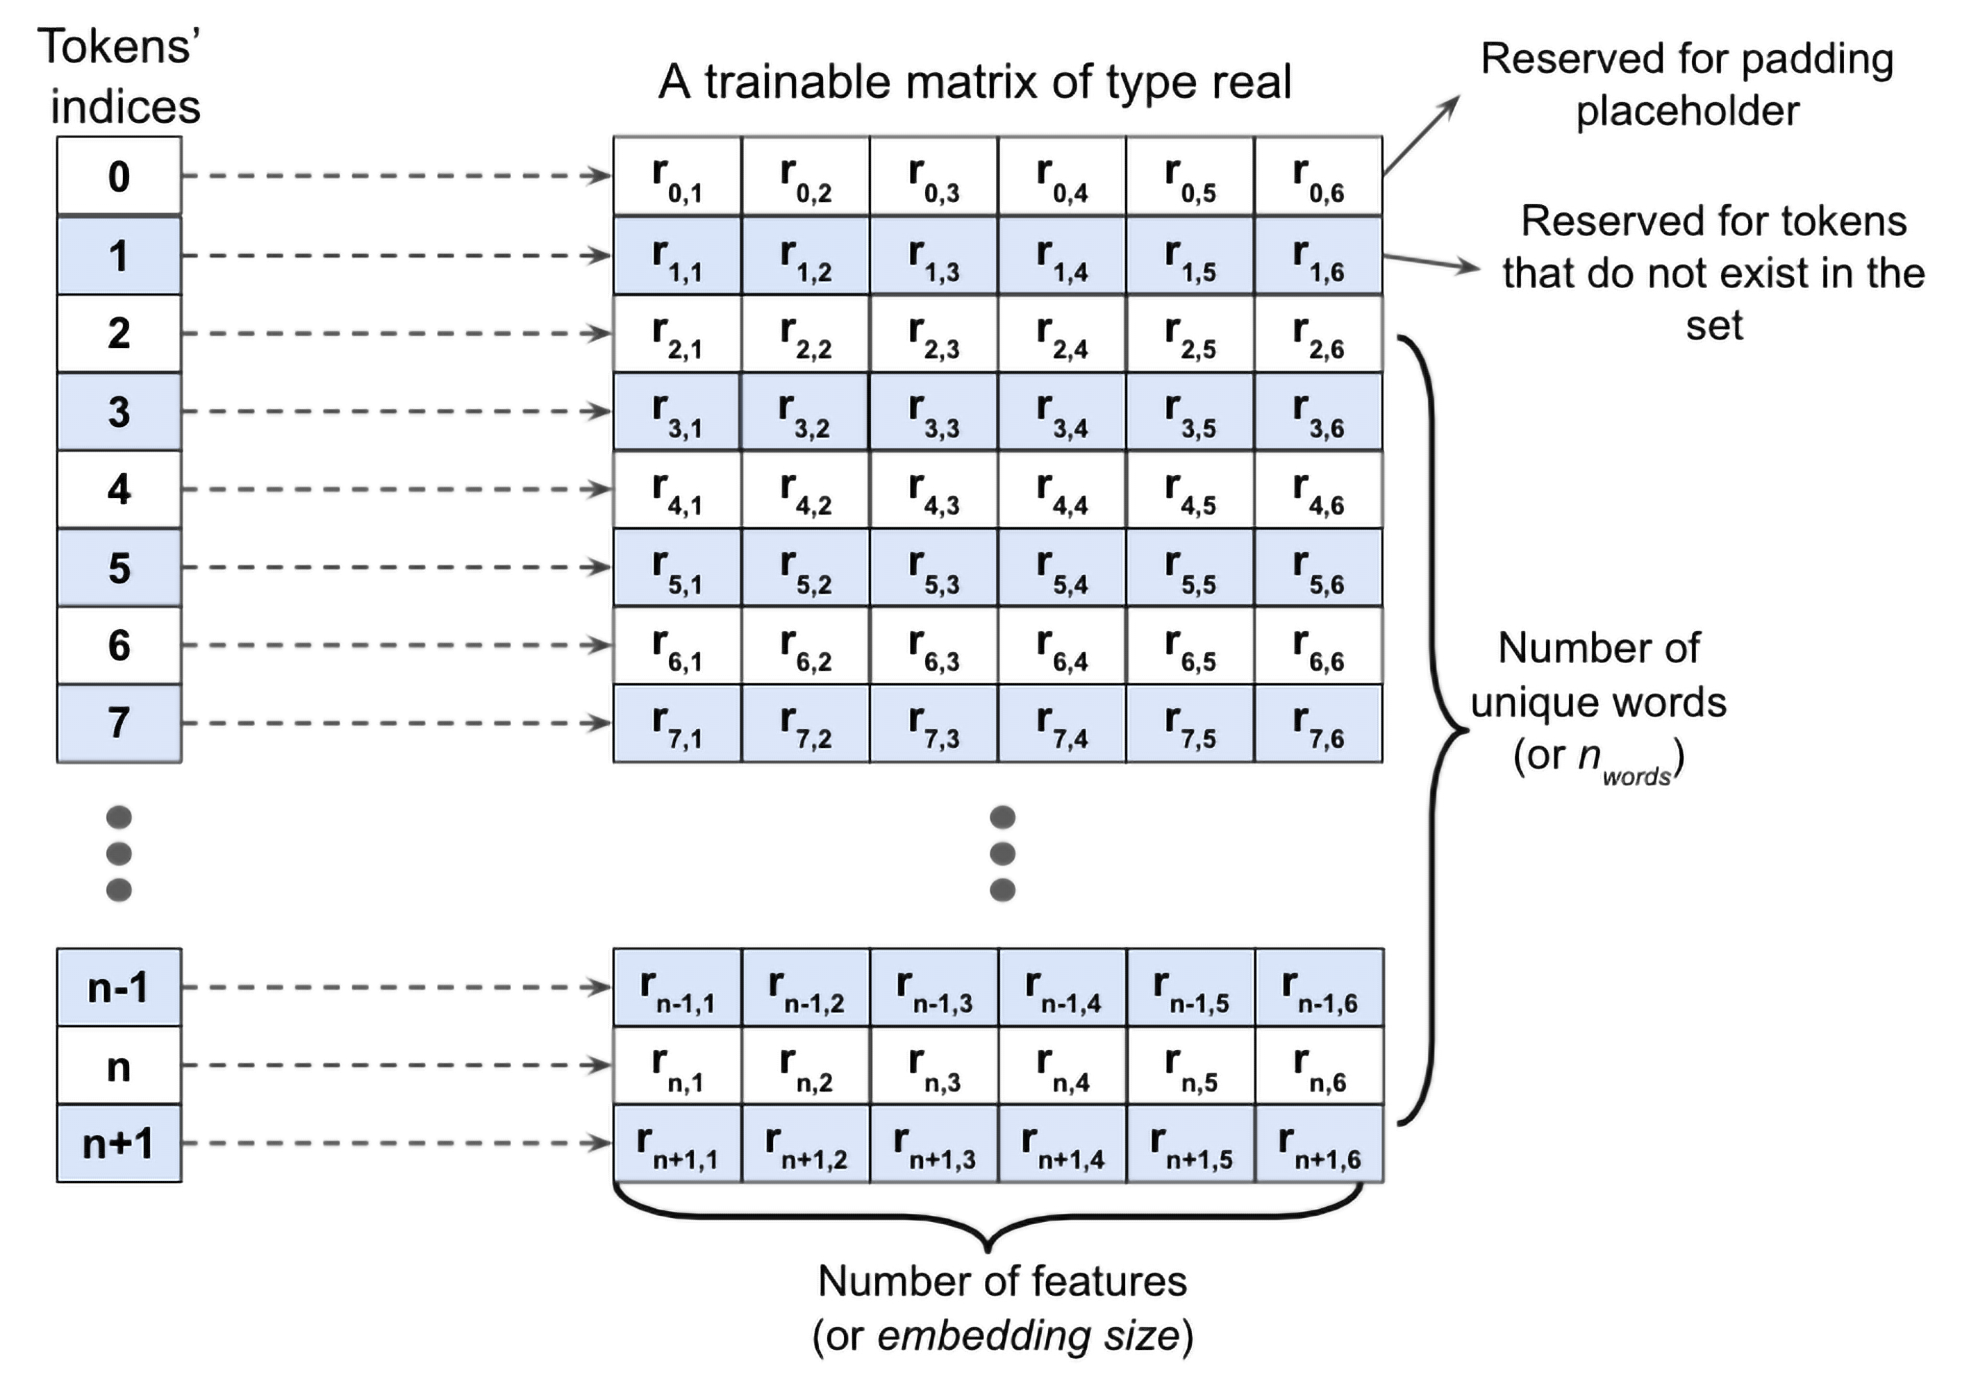

In [9]:
Image(filename='figures/15_10.png', width=600)

In [19]:
# Создаётся слой nn.Embedding — «таблица эмбеддингов», которая каждому целочисленному индексу сопоставляет вектор вещественных чисел. Параметры:
# num_embeddings=10 — в словаре 10 токенов. Значит, допустимые индексы на входе: 0, 1, ..., 9. Если подать индекс 10 или больше — будет ошибка IndexError.
# embedding_dim=3 — каждому токену соответствует вектор длины 3. То есть таблица имеет форму (10, 3).
# padding_idx=0 — индекс 0 объявляется «заполнителем». Для него:
# вектор не будет обучаться (градиенты по нему не считаются, он остаётся нулевым);
# при инициализации этот вектор зануляется.
# Зачем padding_idx? Потому что <pad> — не настоящее слово, а техническая добивка. Учить для него вектор бессмысленно, и он не должен влиять на результат. 
# У нас в словаре <pad> стоит под индексом 0 — поэтому здесь тоже padding_idx=0.
# Внутри nn.Embedding лежит одна матрица весов weight формы (num_embeddings, embedding_dim), то есть (10, 3). Её можно посмотреть:

embedding = nn.Embedding(num_embeddings=10, 
                         embedding_dim=3, 
                         padding_idx=0)
# Батч из 2 примеров, по 4 индекса в каждом
text_encoded_input = torch.LongTensor([[1,2,4,5],[4,3,2,0]])
print(embedding(text_encoded_input))


tensor([[[-1.0233, -0.5962, -1.0055],
         [-0.2106, -0.0075, -1.7869],
         [-0.9962, -0.8313,  1.3075],
         [-1.1628,  0.1196, -0.1631]],

        [[-0.9962, -0.8313,  1.3075],
         [ 1.6103, -0.7040, -0.1853],
         [-0.2106, -0.0075, -1.7869],
         [ 0.0000,  0.0000,  0.0000]]], grad_fn=<EmbeddingBackward0>)


### Построение модели RNN 

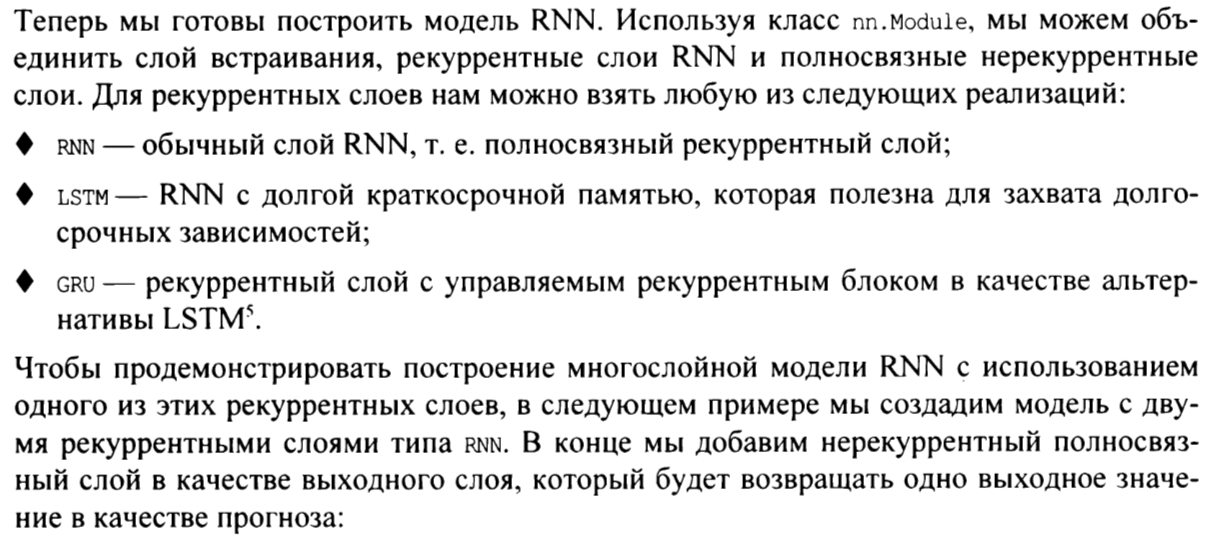

In [10]:
Image(filename='figures/text2.png', width=600)

In [20]:
# Пример построения RNN-модели с простым RNN-слоем

# Полносвязная нейросеть с одним скрытым слоем
class RNN(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.rnn = nn.RNN(input_size, 
                          hidden_size, 
                          num_layers=2, 
                          batch_first=True)
        #self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        #self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)
        
    def forward(self, x):
        _, hidden = self.rnn(x)
        out = hidden[-1, :, :]
        out = self.fc(out)
        return out

model = RNN(64, 32) 

print(model) 
 
model(torch.randn(5, 3, 64)) 

RNN(
  (rnn): RNN(64, 32, num_layers=2, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)


tensor([[0.0589],
        [0.2452],
        [0.0954],
        [0.0423],
        [0.1967]], grad_fn=<AddmmBackward0>)

### Построение модели RNN  для задачи анализа тональности

Поскольку  у  нас  очень  длинные  последовательности,  чтобы  учесть  протяженные эффекты, мы применим слой LSTM.  Создание модели RNN  для анализа тональности (эмоциональной  окраски)  текста  мы начнем  со  слоя  встраивания,  производящего встраивание слов с размером признака 20  (emЬed_dim=20). Затем добавим рекуррентный слой типа LSTM, после чего добавим полносвязный слой в качестве скрытого слоя и еще один полносвязный слой в качестве выходного слоя, который в виде прогноза будет возвращать одно значение вероятности принадлежности к классу через актива­цию логистической сигмоиды: 

In [21]:
class RNN(nn.Module):
    # vocab_size — размер словаря (сколько всего уникальных токенов, включая <pad> и <unk>).
    # embed_dim — размер вектора эмбеддинга для каждого токена.
    # rnn_hidden_size — размер скрытого состояния LSTM.
    # fc_hidden_size — размер скрытого слоя в полносвязной части.
    def __init__(self, vocab_size, embed_dim, rnn_hidden_size, fc_hidden_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        # Слой LSTM (Long Short-Term Memory): 
        self.rnn = nn.LSTM(embed_dim, rnn_hidden_size, batch_first=True)
        # Первый полносвязный слой:
        self.fc1 = nn.Linear(rnn_hidden_size, fc_hidden_size)
        # Функция активации ReLU.
        self.relu = nn.ReLU()
        # Второй полносвязный слой:
        self.fc2 = nn.Linear(fc_hidden_size, 1)
        # Сигмоида 
        self.sigmoid = nn.Sigmoid()

    def forward(self, text, lengths):
        out = self.embedding(text)
        out = nn.utils.rnn.pack_padded_sequence(out, lengths.cpu().numpy(), enforce_sorted=False, batch_first=True)
        out, (hidden, cell) = self.rnn(out)
        out = hidden[-1, :, :]
        out = self.fc1(out)
        out = self.relu(out)
        out = self.fc2(out)
        out = self.sigmoid(out)
        return out
         
vocab_size = len(vocab)
embed_dim = 20
rnn_hidden_size = 64
fc_hidden_size = 64

torch.manual_seed(1)
model = RNN(vocab_size, embed_dim, rnn_hidden_size, fc_hidden_size) 
model = model.to(device)
# Общее число параметров:
# Embedding: vocab_size * 20 ≈ 25002 × 20 ≈ 500k,
# LSTM: примерно 4 * (20*64 + 64*64 + 64) ≈ 4 * (1280 + 4096 + 64) ≈ 21.8k,
# fc1: 64*64 + 64 = 4.2k,
# fc2: 64 + 1 = 65.
# Итого ~526k параметров. Основная масса — в эмбеддингах.

Далее мы разработаем функцию train, которая обучает модель на заданном наборе дан­ных в течение одной эпохи и возвращает точность классификации и потери,
а также функцию оценки для измерения производительности модели на текущем наборе данных: 

In [22]:
def train(dataloader):
    model.train()
    total_acc, total_loss = 0, 0
    for text_batch, label_batch, lengths in dataloader:
        optimizer.zero_grad()
        pred = model(text_batch, lengths)[:, 0]
        loss = loss_fn(pred, label_batch)
        loss.backward()
        optimizer.step()
        total_acc += ((pred>=0.5).float() == label_batch).float().sum().item()
        total_loss += loss.item()*label_batch.size(0)
    return total_acc/len(dataloader.dataset), total_loss/len(dataloader.dataset)
 
def evaluate(dataloader):
    model.eval()
    total_acc, total_loss = 0, 0
    with torch.no_grad():
        for text_batch, label_batch, lengths in dataloader:
            pred = model(text_batch, lengths)[:, 0]
            loss = loss_fn(pred, label_batch)
            total_acc += ((pred>=0.5).float() == label_batch).float().sum().item()
            total_loss += loss.item()*label_batch.size(0)
    return total_acc/len(dataloader.dataset), total_loss/len(dataloader.dataset)

На следующем шаге мы создадим  функцию потерь  и  оптимизатора ( оптимизатор Adam).  Для бинарной классификации с одним выводом вероятности принадлежности к классу мы используем в качестве функции потерь бинарную потерю перекрестной энтропии (BCELoss): 

In [23]:
loss_fn = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 10 

torch.manual_seed(1)
 
for epoch in range(num_epochs):
    acc_train, loss_train = train(train_dl)
    acc_valid, loss_valid = evaluate(valid_dl)
    print(f'Epoch {epoch} accuracy: {acc_train:.4f} val_accuracy: {acc_valid:.4f}')
 

Epoch 0 accuracy: 0.5935 val_accuracy: 0.6562
Epoch 1 accuracy: 0.7287 val_accuracy: 0.7664
Epoch 2 accuracy: 0.8053 val_accuracy: 0.8016
Epoch 3 accuracy: 0.8499 val_accuracy: 0.8352
Epoch 4 accuracy: 0.8580 val_accuracy: 0.8108
Epoch 5 accuracy: 0.8926 val_accuracy: 0.8462
Epoch 6 accuracy: 0.9160 val_accuracy: 0.8564
Epoch 7 accuracy: 0.9337 val_accuracy: 0.8630
Epoch 8 accuracy: 0.8963 val_accuracy: 0.8544
Epoch 9 accuracy: 0.9528 val_accuracy: 0.8562


In [24]:
acc_test, _ = evaluate(test_dl)
print(f'test_accuracy: {acc_test:.4f}') 

test_accuracy: 0.8366


Тест показал точность 83%.  Заметим, что этот результат не самый лучший по сравне­нию с современными методами, применяемыми к набору данных IMDb. Но наша цель здесь состояла в том, чтобы просто продемонстрировать создание RNN в PyTorch.

### Подробнее о двунаправленной RNN

Давайте теперь установим значение параметра bidirectional слоя LSTM в True, что заста­вит рекуррентный слой проходить через входные последовательности с обоих направ­лений: от начала до конца, а также в обратном направлении: 

In [25]:
class RNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, rnn_hidden_size, fc_hidden_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, 
                                      embed_dim, 
                                      padding_idx=0) 
        self.rnn = nn.LSTM(embed_dim, rnn_hidden_size, 
                           batch_first=True, bidirectional=True)
        self.fc1 = nn.Linear(rnn_hidden_size*2, fc_hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(fc_hidden_size, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, text, lengths):
        out = self.embedding(text)
        out = nn.utils.rnn.pack_padded_sequence(out, lengths.cpu().numpy(), enforce_sorted=False, batch_first=True)
        _, (hidden, cell) = self.rnn(out)
        out = torch.cat((hidden[-2, :, :], hidden[-1, :, :]), dim=1)
        out = self.fc1(out)
        out = self.relu(out)
        out = self.fc2(out)
        out = self.sigmoid(out)
        return out
    
torch.manual_seed(1)
model = RNN(vocab_size, embed_dim, rnn_hidden_size, fc_hidden_size) 
model = model.to(device)

In [26]:
loss_fn = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.002)

num_epochs = 10 

torch.manual_seed(1)
 
for epoch in range(num_epochs):
    acc_train, loss_train = train(train_dl)
    acc_valid, loss_valid = evaluate(valid_dl)
    print(f'Epoch {epoch} accuracy: {acc_train:.4f} val_accuracy: {acc_valid:.4f}')

Epoch 0 accuracy: 0.6293 val_accuracy: 0.7384
Epoch 1 accuracy: 0.7557 val_accuracy: 0.7666
Epoch 2 accuracy: 0.8250 val_accuracy: 0.8290
Epoch 3 accuracy: 0.8821 val_accuracy: 0.8558
Epoch 4 accuracy: 0.9222 val_accuracy: 0.8624
Epoch 5 accuracy: 0.9486 val_accuracy: 0.8670
Epoch 6 accuracy: 0.9656 val_accuracy: 0.8620
Epoch 7 accuracy: 0.9755 val_accuracy: 0.8768
Epoch 8 accuracy: 0.9858 val_accuracy: 0.8736
Epoch 9 accuracy: 0.9866 val_accuracy: 0.8654


Двунаправленный слой RNN  выполняет два прохода по каждой входной последова­тельности: прямой и обратный (будьте внимательны, и не путайте их с прямым и об­ратным проходами в контексте обратного распространения ошибки). Результирующие скрытые состояния этих прямых и обратных проходов обычно объединяются в одно скрытое состояние путем конкатенации. Возможны и другие способы слияния: сумми­рование, умножение (умножение результатов двух проходов)  и  усреднеднение  (взятие среднего из двух результатов). Можно также попробовать иные типы рекуррентных слоев - например, обычный RNN. 
Однако, как оказалось, модель, построенная с использованием обычных рекуррентных слоев, не сможет достичь хороших результатов прогнозирования (даже на обучающих данных).  Например,  если  вы попытаетесь  заменить двунаправленный  слой  LSTM в приведенном коде однонаправленным слоем nn.RNN  (вместо nn.LSTM) и обучите модель на полноразмерных последовательностях, вы можете заметить, что потери на протяже­нии обучения даже не уменьшаются. Причина в том, что последовательности в этом наборе данных слишком длинные, поэтому модель со слоем RNN не в состоянии изучить долгосрочные зависимости и может страдать от проблем с исчезновением или взрывом градиента.

In [27]:
# test_dataset = IMDB(split='test')
# test_dl = DataLoader(test_dataset, batch_size=batch_size,
#                      shuffle=False, collate_fn=collate_batch)

In [28]:
# acc_test, _ = evaluate(test_dl)
# print(f'test_accuracy: {acc_test:.4f}') 